Import Libraries

In [9]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, precision_recall_curve
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

Load Dataset

In [2]:
data = pd.read_csv('../data/customers_transactions_features.csv')

Basic info

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 40 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   CustomerID            1000000 non-null  int64  
 1   Age                   1000000 non-null  int64  
 2   Gender                1000000 non-null  object 
 3   MaritalStatus         1000000 non-null  object 
 4   Education             1000000 non-null  object 
 5   EmploymentStatus      1000000 non-null  object 
 6   Income                1000000 non-null  float64
 7   LoanAmount            1000000 non-null  float64
 8   NumLoans              1000000 non-null  int64  
 9   CreditHistoryLength   1000000 non-null  int64  
 10  AvgMonthlyExpenses    1000000 non-null  float64
 11  Savings               1000000 non-null  float64
 12  CreditCardUsage       1000000 non-null  object 
 13  MobileMoneyUsage      1000000 non-null  object 
 14  LatePayments          1000000 non-n

Descriptive Analysis

In [4]:
data.describe(include='all')

,CustomerID,Age,Gender,MaritalStatus,Education,EmploymentStatus,Income,LoanAmount,NumLoans,CreditHistoryLength,...,FraudRate,ChannelRatio_ATM,ChannelRatio_Mobile,ChannelRatio_Online,ChannelRatio_POS,TimeRatio_Afternoon,TimeRatio_Evening,TimeRatio_Morning,TimeRatio_Night,WeekendActivityRatio
count,1000000.000000,1000000.000000,1000000,1000000,1000000,1000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,...,99990.0,99990.000000,99990.000000,99990.000000,99990.000000,99990.000000,99990.000000,99990.000000,99990.000000,99990.000000
unique,NaN,NaN,2,4,6,5,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Female,Single,Secondary,Employed,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,500284,449876,399935,499943,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,500000.500000,44.639115,NaN,NaN,NaN,NaN,45311.232915,24651.348376,1.878262,13.006905,...,0.0,0.149706,0.099834,0.400343,0.350117,0.350528,0.299542,0.249992,0.099937,0.285812
std,288675.278932,14.646523,NaN,NaN,NaN,NaN,22544.952138,24821.488807,1.333260,7.466509,...,0.0,0.119444,0.100268,0.164944,0.160537,0.160071,0.154246,0.145065,0.100614,0.152410
min,1.000000,18.000000,NaN,NaN,NaN,NaN,5000.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,250000.750000,32.000000,NaN,NaN,NaN,NaN,30837.932500,5305.095000,1.000000,6.000000,...,0.0,0.071429,0.000000,0.285714,0.250000,0.250000,0.200000,0.142857,0.000000,0.181818
50%,500000.500000,46.000000,NaN,NaN,NaN,NaN,47150.220000,16944.685000,2.000000,13.000000,...,0.0,0.142857,0.090909,0.400000,0.333333,0.333333,0.285714,0.250000,0.090909,0.285714
75%,750000.250000,55.000000,NaN,NaN,NaN,NaN,61467.170000,36417.807500,3.000000,20.000000,...,0.0,0.222222,0.166667,0.500000,0.454545,0.454545,0.400000,0.333333,0.166667,0.375000


Handle Null Values

In [5]:
if data.isnull().sum().sum() == 0:
    print("No null values found.")
else:
    print("Null values found:")
    print(data.isnull().sum())
    data.fillna(0, inplace=True)
    print("Null values filled with 0.")

Null values found:
CustomerID                   0
Age                          0
Gender                       0
MaritalStatus                0
Education                    0
EmploymentStatus             0
Income                       0
LoanAmount                   0
NumLoans                     0
CreditHistoryLength          0
AvgMonthlyExpenses           0
Savings                      0
CreditCardUsage              0
MobileMoneyUsage             0
LatePayments                 0
Default                      0
DebtToIncome                 0
ExpenseRatio                 0
SavingsRate                  0
LoansPerYearHistory          0
HighDebtFlag                 0
LowSavingsFlag               0
FrequentLatePayer            0
CreditCardUsageEnc           0
MobileMoneyUsageEnc          0
TotalTransactions       900010
AvgTransactionAmount    900010
MaxTransactionAmount    900010
TransactionStdDev       900056
TotalFrauds             900010
FraudRate               900010
ChannelRatio_ATM    

In [6]:
data.columns

Index(['CustomerID', 'Age', 'Gender', 'MaritalStatus', 'Education',
       'EmploymentStatus', 'Income', 'LoanAmount', 'NumLoans',
       'CreditHistoryLength', 'AvgMonthlyExpenses', 'Savings',
       'CreditCardUsage', 'MobileMoneyUsage', 'LatePayments', 'Default',
       'DebtToIncome', 'ExpenseRatio', 'SavingsRate', 'LoansPerYearHistory',
       'HighDebtFlag', 'LowSavingsFlag', 'FrequentLatePayer',
       'CreditCardUsageEnc', 'MobileMoneyUsageEnc', 'TotalTransactions',
       'AvgTransactionAmount', 'MaxTransactionAmount', 'TransactionStdDev',
       'TotalFrauds', 'FraudRate', 'ChannelRatio_ATM', 'ChannelRatio_Mobile',
       'ChannelRatio_Online', 'ChannelRatio_POS', 'TimeRatio_Afternoon',
       'TimeRatio_Evening', 'TimeRatio_Morning', 'TimeRatio_Night',
       'WeekendActivityRatio'],
      dtype='object')

TRAINING PIPELINE

Empty DataFrame
Columns: [Task, Model, Accuracy, Precision, Recall, F1, ROC-AUC]
Index: []

Best models selected:
Empty DataFrame
Columns: [Task, Model, Accuracy, Precision, Recall, F1, ROC-AUC]
Index: []


/tmp/ipykernel_75549/3358970044.py:116: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


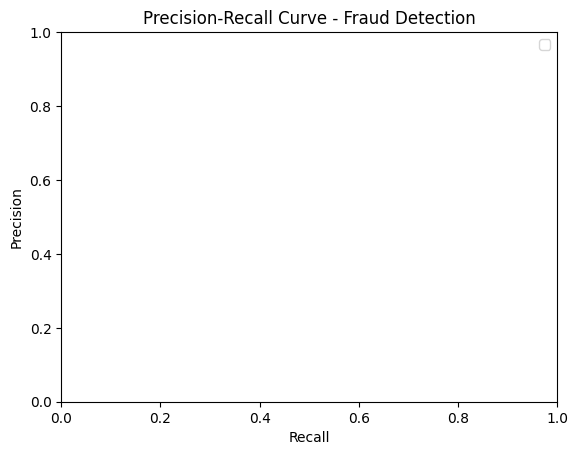

AttributeError: 'NoneType' object has no attribute 'feature_importances_'

In [ ]:
# Encoding categorical features
categorical_features = data.select_dtypes(include=['object']).columns
for col in categorical_features:
    if data[col].nunique() <= 10:
        encoder = OneHotEncoder(sparse_output=False)
        encoded = encoder.fit_transform(data[[col]])
        encoded_df = pd.DataFrame(encoded, columns=[f"{col}_{cat}" for cat in encoder.categories_[0]])
        data = pd.concat([data.drop(columns=[col]), encoded_df], axis=1)
    else:
        le = LabelEncoder()
        data[col] = le.fit_transform(data[col])

# Credit scoring
target_credit = "Default"
X_credit = data.drop(columns=[target_credit, "FraudRate", 'CustomerID'])
y_credit = data[target_credit]

# Fraud detection
target_fraud = "FraudRate"
X_fraud = data.drop(columns=[target_fraud, target_credit, 'CustomerID'])
y_fraud = data[target_fraud]

# Split datasets
Xc_train, Xc_test, yc_train, yc_test = train_test_split(X_credit, y_credit, test_size=0.2, random_state=42, stratify=y_credit)
Xf_train, Xf_test, yf_train, yf_test = train_test_split(X_fraud, y_fraud, test_size=0.2, random_state=42, stratify=y_fraud)

# Standardize for Logistic Regression
scaler = StandardScaler()
Xc_train_scaled = scaler.fit_transform(Xc_train)
Xc_test_scaled = scaler.transform(Xc_test)

# Save scaler for future use
joblib.dump(scaler, "credit_scaler.pkl")

# Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42),
    "XGBoost": XGBClassifier(eval_metric="logloss", use_label_encoder=False)
}

# Training & evaluating the models
def evaluate_models(X_train, X_test, y_train, y_test, task_name):
    results = []
    trained_models = {}

    # Check if there are at least two classes in y_train and y_test
    if len(np.unique(y_train)) < 2 or len(np.unique(y_test)) < 2:
        print(f"Warning: {task_name} - Only one class present in training or test data. Skipping model training.")
        return results, trained_models

    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, zero_division=0)
        rec = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)
        auc = roc_auc_score(y_test, y_prob)

        results.append([task_name, name, acc, prec, rec, f1, auc])
        trained_models[name] = model

        # ROC curve
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.2f})")

    plt.plot([0, 1], [0, 1], '--', color='gray')
    plt.title(f"ROC Curve - {task_name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()

    return results, trained_models

# Evaluate Credit Scoring
credit_results, credit_models = evaluate_models(Xc_train_scaled, Xc_test_scaled, yc_train, yc_test, "Credit Scoring")

# Evaluate Fraud Detection
fraud_results, fraud_models = evaluate_models(Xf_train, Xf_test, yf_train, yf_test, "Fraud Detection")

# Combine results
results_df = pd.DataFrame(credit_results + fraud_results, columns=["Task", "Model", "Accuracy", "Precision", "Recall", "F1", "ROC-AUC"])
print(results_df)

# Select best models by ROC-AUC
best_models = results_df.loc[results_df.groupby("Task")["ROC-AUC"].idxmax()]
print("\nBest models selected:")
print(best_models)

# Save best models
if not best_models.empty:
    for _, row in best_models.iterrows():
        task = row["Task"]
        model_name = row["Model"]
        if task.startswith("Credit"):
            best_model = credit_models[model_name]
        else:
            best_model = fraud_models[model_name]
        filename = f"best_{task.replace(' ', '_').lower()}_{model_name.lower().replace(' ', '_')}.pkl"
        joblib.dump(best_model, filename)
        print(f"Saved: {filename}")

# Precision-Recall curve for fraud detection
for name, model in fraud_models.items():
    y_prob = model.predict_proba(Xf_test)[:, 1]
    prec, rec, _ = precision_recall_curve(yf_test, y_prob)
    plt.plot(rec, prec, label=f"{name}")

plt.title("Precision-Recall Curve - Fraud Detection")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

# Feature importance (XGBoost - Fraud)
xgb_fraud = fraud_models.get("XGBoost")
importances = xgb_fraud.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices][:20], y=X_fraud.columns[indices][:20])
plt.title("Top 20 Feature Importances (Fraud Detection)")
plt.show()

# SHAP values (Fraud)
explainer = shap.TreeExplainer(xgb_fraud)
shap_values = explainer.shap_values(Xf_test[:200])  # sample for speed
shap.summary_plot(shap_values, Xf_test[:200])

PREDICTION

In [ ]:
def score_new_data(new_data_csv):
    """Load new customer/transaction data and score using best saved models."""

    # Load new data
    new_data = pd.read_csv(new_data_csv)

    # Load scaler
    scaler = joblib.load("credit_scaler.pkl")

    # Load best models
    credit_model = joblib.load("best_credit_scoring_xgboost.pkl") if os.path.exists("best_credit_scoring_xgboost.pkl") else None
    fraud_model = joblib.load("best_fraud_detection_xgboost.pkl") if os.path.exists("best_fraud_detection_xgboost.pkl") else None

    results = {}

    if credit_model:
        X_new_credit = new_data.drop(columns=["FraudRate"], errors="ignore")
        X_new_credit_scaled = scaler.transform(X_new_credit)
        new_data["CreditRisk"] = credit_model.predict_proba(X_new_credit_scaled)[:, 1]
        results["CreditRisk"] = new_data[["CreditRisk"]]

    if fraud_model:
        X_new_fraud = new_data.drop(columns=["Defaulted"], errors="ignore")
        new_data["FraudProbability"] = fraud_model.predict_proba(X_new_fraud)[:, 1]
        results["FraudProbability"] = new_data[["FraudProbability"]]

    # Save results
    new_data.to_csv("scored_new_data.csv", index=False)
    print("Scoring complete and saved to 'scored_new_data.csv'")
    return results
